In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
from cartopy import crs as ccrs # Cartography library
import geopy.distance
import re
import pandas as pd
import cartopy.feature as cfeature
import matplotlib.patches as patches
from matplotlib.legend_handler import HandlerTuple
import cmocean # Colormap library
import cmweather as cmw

In [2]:
### Link of the data
root = "ipfs://QmWCvrM2jwRjXpzkiDNPzhkz1XrZBJwF1j3cCx9yBJ92GB"

In [3]:
### Calling radiosondes from METEOR
ds_windcube= xr.open_dataset(
    f"{root}/WindCube/WLS200s-180-dbs-1397-25m.zarr",engine="zarr")
dset_meteo = xr.open_dataset(f"{root}/DShip.zarr",engine="zarr")
ds_wabacus= xr.open_dataset(f"{root}/WindLidar-Abacus/v2.0.zarr",engine="zarr")

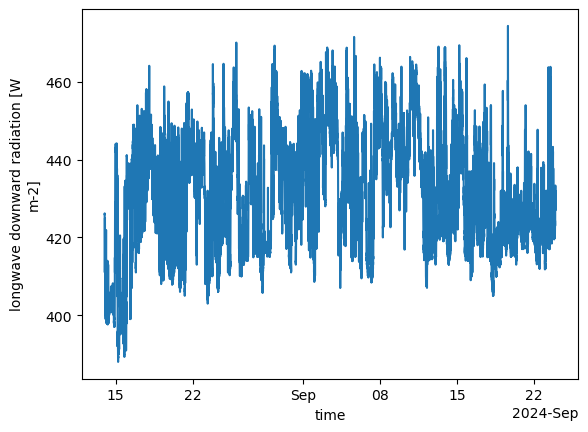

In [4]:
dset_meteo.lwr.plot()

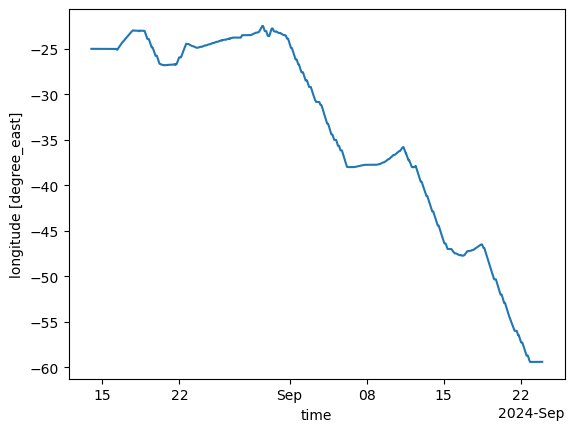

In [6]:
dset_meteo.lon.plot()

In [13]:
ds_wabacus_rmean = ds_wabacus.wind.rolling(time=30,center=True).mean()

In [5]:
root_radio = 'ipfs://QmSUUUPcGcpwdJJCVDGPGYksLsqkWbfh6d6xFcTk2Qu7Zf'
dset_radio = xr.open_dataset(f"{root_radio}/RAPSODI_RS_ORCESTRA_level2.zarr",engine="zarr")

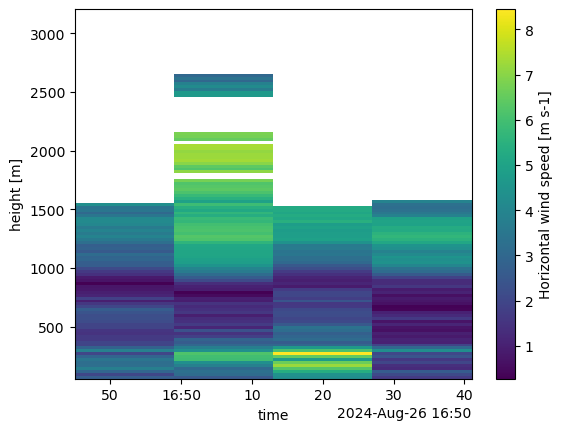

In [6]:
ds_windcube.sel(
    time=slice('2024-08-26 16:49:40','2024-08-26 16:55')).wind_speed.plot(y='height')

In [7]:
dset_rad_meteor= dset_radio.where((dset_radio.platform=='RV_Meteor') & (dset_radio.ascent_flag==0),drop=True)

In [8]:
dset_rad_meteor.sel(launch_time=slice('2024-08-26 16:00','2024-08-26 18:00'),alt=slice(0,3000)).launch_time

<xarray.DataArray 'launch_time' (launch_time: 1)> Size: 8B
array(['2024-08-26T16:50:24.403000000'], dtype='datetime64[ns]')
Coordinates:
  * launch_time  (launch_time) datetime64[ns] 8B 2024-08-26T16:50:24.403000
    launch_lat   (launch_time) float32 4B 12.64
    launch_lon   (launch_time) float32 4B -23.82
    sounding     (launch_time) <U46 184B 'RV Meteor__ascent__12.64_-23.82__20...
Attributes:
    long_name:      time at which the sounding started
    standard_name:  time

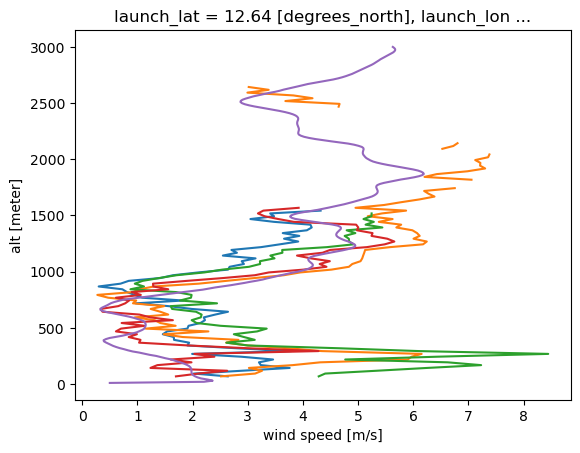

In [9]:
ds_windcube.sel(
    time=slice('2024-08-26 16:49:40','2024-08-26 16:55')).isel(time=0).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-08-26 16:49:40','2024-08-26 16:55')).isel(time=1).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-08-26 16:49:40','2024-08-26 16:55')).isel(time=2).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-08-26 16:49:40','2024-08-26 16:55')).isel(time=3).wind_speed.plot(y='height')
dset_rad_meteor.sel(launch_time=slice('2024-08-26 16:00','2024-08-26 18:00'),alt=slice(0,3000)).wspd.plot(y='alt')

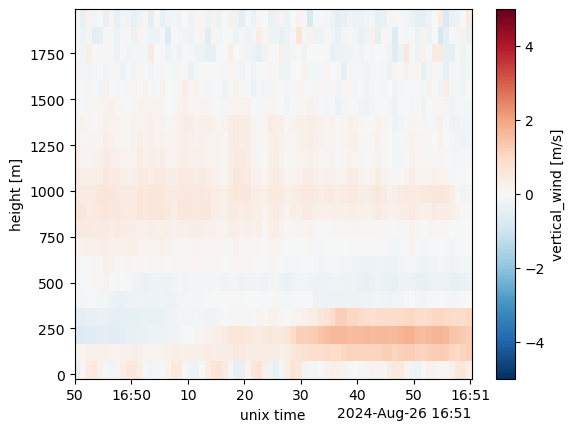

In [10]:
ds_wabacus.sel(
    time=slice('2024-08-26 16:49:50','2024-08-26 16:50'),
    height=slice(0,2000)).wind.plot(y='height',vmin=-5,vmax=5,cmap='RdBu_r')

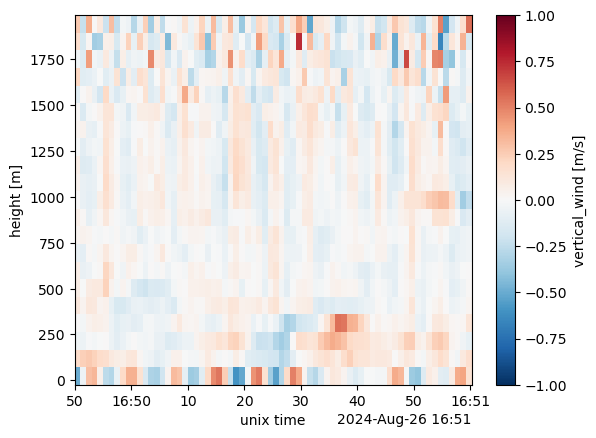

In [14]:
(ds_wabacus.sel(
    time=slice('2024-08-26 16:49:50','2024-08-26 16:50'),
    height=slice(0,2000)).wind - ds_wabacus_rmean).plot(y='height',vmin=-1,vmax=1,cmap='RdBu_r')

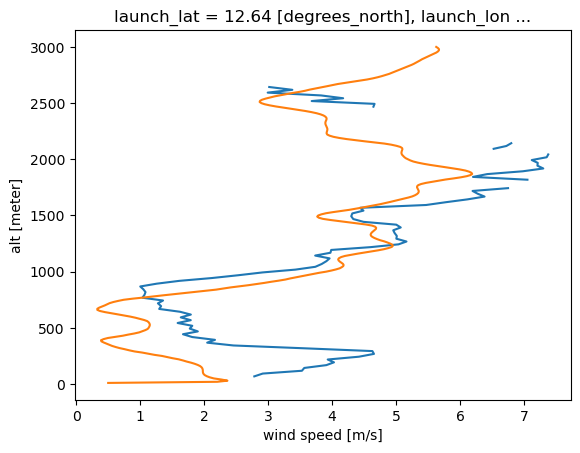

In [86]:
ds_windcube.sel(
    time=slice('2024-08-26 16:49:40','2024-08-26 16:55')).mean('time').wind_speed.plot(y='height')
dset_rad_meteor.sel(launch_time=slice('2024-08-26 16:00','2024-08-26 18:00'),alt=slice(0,3000)).wspd.plot(y='alt')

In [77]:
dset_rad_meteor.sel(launch_time=slice('2024-08-26 18:00','2024-08-26 23:00')).launch_time

<xarray.DataArray 'launch_time' (launch_time: 2)> Size: 16B
array(['2024-08-26T19:51:00.813016000', '2024-08-26T22:50:22.657025984'],
      dtype='datetime64[ns]')
Coordinates:
  * launch_time  (launch_time) datetime64[ns] 16B 2024-08-26T19:51:00.813016 ...
    launch_lat   (launch_time) float32 8B 13.0 13.04
    launch_lon   (launch_time) float32 8B -23.77 -23.76
    sounding     (launch_time) <U46 368B 'RV Meteor__ascent__13.00_-23.77__20...
Attributes:
    long_name:      time at which the sounding started
    standard_name:  time

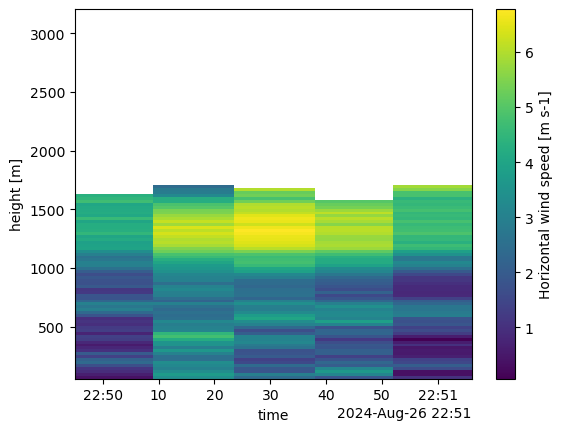

In [83]:
ds_windcube.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:55')).wind_speed.plot(y='height')

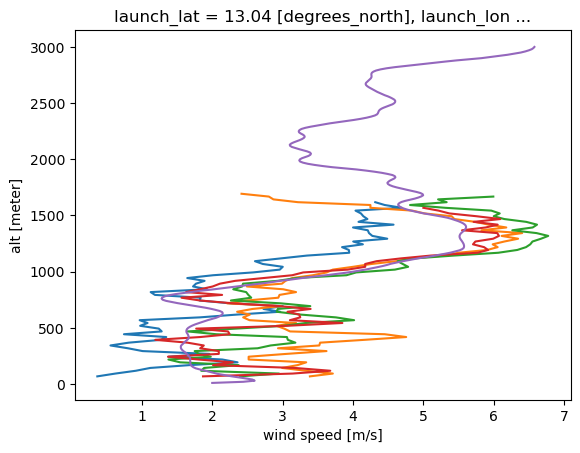

In [84]:
ds_windcube.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:55')).isel(time=0).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:55')).isel(time=1).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:55')).isel(time=2).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:55')).isel(time=3).wind_speed.plot(y='height')
dset_rad_meteor.sel(launch_time=slice('2024-08-26 22:00','2024-08-26 23:00'),alt=slice(0,3000)).wspd.plot(y='alt')

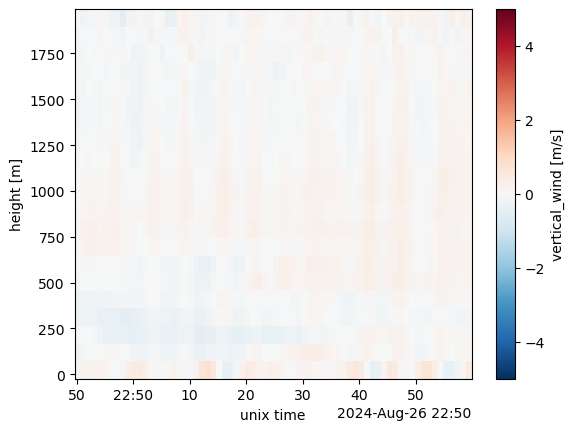

In [20]:
ds_wabacus.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:50'),
    height=slice(0,2000)).wind.plot(y='height',vmin=-5,vmax=5,cmap='RdBu_r')

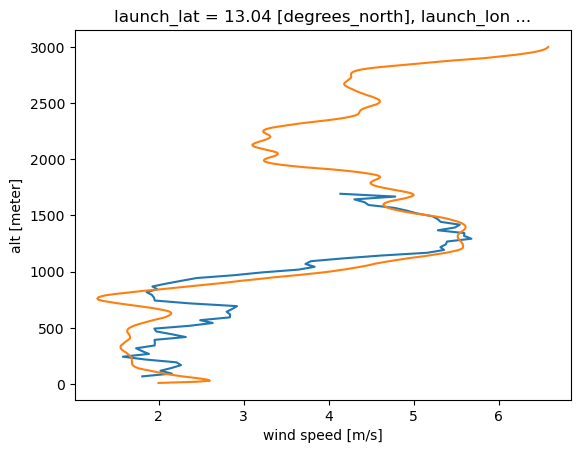

In [85]:
ds_windcube.sel(
    time=slice('2024-08-26 22:49:50','2024-08-26 22:55')).mean('time').wind_speed.plot(y='height')
dset_rad_meteor.sel(launch_time=slice('2024-08-26 22:00','2024-08-26 23:00'),alt=slice(0,3000)).wspd.plot(y='alt')

In [79]:
dset_rad_meteor.sel(launch_time=slice('2024-08-26 16:00','2024-08-26 18:00')).launch_time

<xarray.DataArray 'launch_time' (launch_time: 1)> Size: 8B
array(['2024-08-26T16:50:24.403000000'], dtype='datetime64[ns]')
Coordinates:
  * launch_time  (launch_time) datetime64[ns] 8B 2024-08-26T16:50:24.403000
    launch_lat   (launch_time) float32 4B 12.64
    launch_lon   (launch_time) float32 4B -23.82
    sounding     (launch_time) <U46 184B 'RV Meteor__ascent__12.64_-23.82__20...
Attributes:
    long_name:      time at which the sounding started
    standard_name:  time

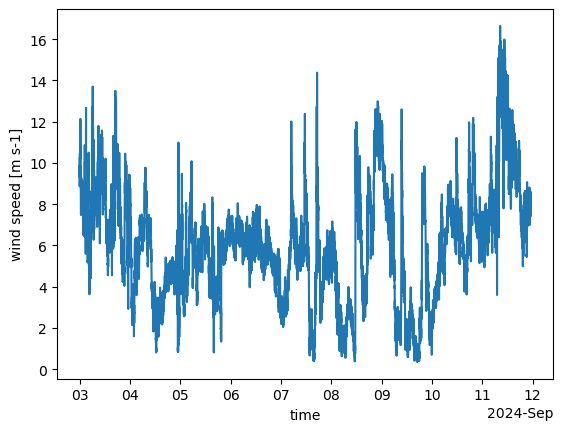

In [116]:
dset_meteo.wspd.sel(time=slice('2024-09-03','2024-09-11 22:55')).plot()

In [120]:
dset_rad_meteor.sel(launch_time=slice('2024-09-07 00:00','2024-09-07 06:00')).launch_time

<xarray.DataArray 'launch_time' (launch_time: 2)> Size: 16B
array(['2024-09-07T01:49:55.982996000', '2024-09-07T04:49:56.587012000'],
      dtype='datetime64[ns]')
Coordinates:
  * launch_time  (launch_time) datetime64[ns] 16B 2024-09-07T01:49:55.982996 ...
    launch_lat   (launch_time) float32 8B 9.201 9.718
    launch_lon   (launch_time) float32 8B -37.94 -37.9
    sounding     (launch_time) <U46 368B 'RV Meteor__ascent__9.20_-37.94__202...
Attributes:
    long_name:      time at which the sounding started
    standard_name:  time

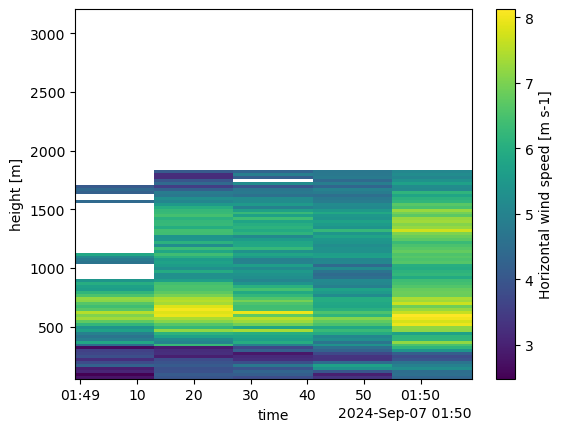

In [124]:
ds_windcube.sel(
    time=slice('2024-09-07 01:49:00','2024-09-07 01:50')).wind_speed.plot(y='height')

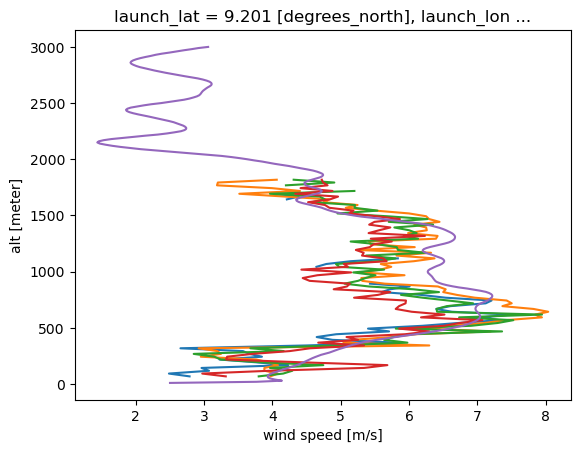

In [125]:
ds_windcube.sel(
    time=slice('2024-09-07 01:49:00','2024-09-07 01:50')).isel(time=0).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-09-07 01:49:00','2024-09-07 01:50')).isel(time=1).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-09-07 01:49:00','2024-09-07 01:50')).isel(time=2).wind_speed.plot(y='height')
ds_windcube.sel(
    time=slice('2024-09-07 01:49:00','2024-09-07 01:50')).isel(time=3).wind_speed.plot(y='height')
dset_rad_meteor.sel(launch_time=slice('2024-09-07 01:00','2024-09-07 02:00'),alt=slice(0,3000)).wspd.plot(y='alt')

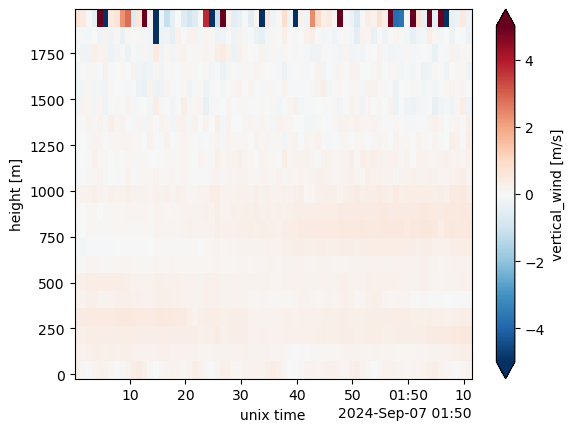

In [22]:
ds_wabacus.sel(
    time=slice('2024-09-07 01:49:00','2024-09-07 01:50:10'),
    height=slice(0,2000)).wind.plot(y='height',vmin=-5,vmax=5,cmap='RdBu_r')

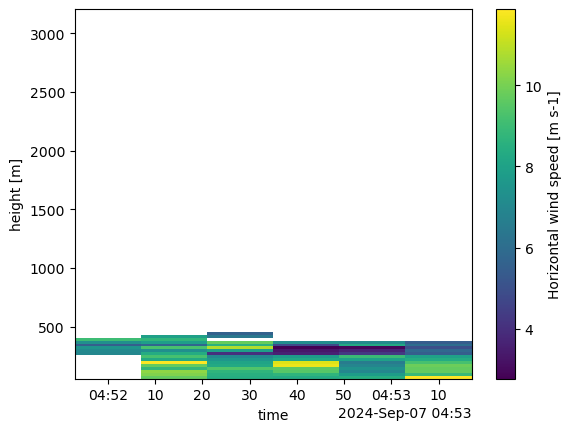

In [126]:
ds_windcube.sel(
    time=slice('2024-09-07 04:48:00','2024-09-07 05:00')).wind_speed.plot(y='height')